# Part 2: Simple Text Processing - Tokenization, Lemmatization, Word Frequency, Vectorization 

In [162]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns

import os
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-dark') 


In [163]:
OUTPUT_DIR = 'outputs'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

In [3]:
import spacy
from tqdm import tqdm
from collections import Counter

nlp = spacy.load("en_core_web_sm")

In [4]:
sou = pd.read_csv('data/SOTU.csv')
sou

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
...,...,...,...,...
241,George Washington,1791.0,\nFellow-Citizens of the Senate and House of R...,2264
242,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
243,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
244,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069


### Processing Speeches with SpaCy

In [26]:
above_2000 = sou[sou['Year'] >= 2000].copy()
above_2000

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
5,Donald J. Trump,2019.0,"\nThe President. Madam Speaker, Mr. Vice Presi...",5519
6,Donald J. Trump,2018.0,"\nThe President. Mr. Speaker, Mr. Vice Preside...",5755
7,Donald J. Trump,2017.0,"\nThank you very much. Mr. Speaker, Mr. Vice P...",4903
8,Barack Obama,2016.0,"\nThank you. Mr. Speaker, Mr. Vice President, ...",5956
9,Barack Obama,2015.0,"\nThe President. Mr. Speaker, Mr. Vice Preside...",6659


The table is filtered with those rows that contain the speeches made in the year 2000 and after. Each speech is then iterated through the 'nlp' function which extracts a clean list of lemmas by filtering out stop words, punctuation, spaces, and numerics.

In [27]:
text_generator = above_2000['Text'].tolist()
docs = list(nlp.pipe(text_generator, disable=["parser", "ner"]))

all_clean_lemmas = []

for doc in tqdm(docs, desc="Extracting Tokens"):

    clean_tokens = [
        token.lemma_
        for token in doc          
        if not token.is_stop       
        and not token.is_punct    
        and not token.is_space   
        and not token.like_num  
        and token.is_alpha
    ]
    all_clean_lemmas.extend(clean_tokens)

Extracting Tokens: 100%|██████████| 25/25 [00:00<00:00, 391.23it/s]


### Analyze Tokens vs Lemmas

#### Token List

In [29]:
all_clean_tokens = []

for doc in docs:
    clean_tokens = [
        token.text.lower()
        for token in doc
        if not token.is_stop 
        and not token.is_punct 
        and not token.is_space 
        and not token.like_num 
        and token.is_alpha 
    ]
    all_clean_tokens.extend(clean_tokens)

token_list = all_clean_tokens

word_counts_raw = Counter(token_list)
top_20_tokens = word_counts_raw.most_common(20)

top_20_tokens

[('america', 816),
 ('people', 637),
 ('american', 582),
 ('new', 530),
 ('years', 439),
 ('americans', 437),
 ('world', 425),
 ('year', 406),
 ('country', 369),
 ('jobs', 348),
 ('tonight', 344),
 ('work', 324),
 ('know', 323),
 ('let', 320),
 ('congress', 317),
 ('nation', 311),
 ('time', 301),
 ('help', 282),
 ('need', 266),
 ('tax', 255)]

This list contains tokens across all speeches that are not spaces, stopwords, or punctuation and each token made lowercase. Only the top 20 most common tokens are shown.

#### Lemma List


In [31]:

all_clean_lemmas = []

for doc in docs:
    clean_lemmas = [
        token.lemma_.lower() 
        for token in doc          
        if not token.is_stop     
        and not token.is_punct     
        and not token.is_space  
        and not token.like_num 
        and token.is_alpha 
    ]
    all_clean_lemmas.extend(clean_lemmas)
word_counts_lemma = Counter(all_clean_lemmas)
top_20_lemmas = word_counts_lemma.most_common(20)

top_20_lemmas

[('year', 845),
 ('america', 816),
 ('people', 639),
 ('american', 587),
 ('work', 557),
 ('new', 532),
 ('job', 486),
 ('country', 435),
 ('americans', 432),
 ('world', 426),
 ('know', 395),
 ('nation', 388),
 ('help', 386),
 ('need', 353),
 ('time', 351),
 ('tonight', 344),
 ('child', 332),
 ('let', 326),
 ('congress', 317),
 ('come', 302)]

This list contains the top 20 most common lemmas from across all speeches that are not spaces, stopwords, or punctuation and made lowercase. 

#### Token versus Lemma Comparison


The top tokens and the top lemmas differ. The count in lemma frequency seems be larger or equal than in tokens. This is because in lemma frequency it is counting the base words and token counts the exact word. An example of this is shown in "year" and "years". Their token frequency is considered seperately so they are smaller but in lemma frequency the count of "year" is much larger because it considers "years" and "year". "child" only appears in the top 20 of the lemmas list because it includes the count of other words containing "child" such as "children" for example.

### Common Words

#### Common Words per Year Function

In [40]:
def get_most_common_words(df, year, n=25):
    """
    Processes the SOTU speech for a given year and returns
    the most common non-stopword/punctuation lemmas.
    """

    # Step 1: Subset df
    speech_df = df[df['Year'] == year].copy()

    # Step 2: Process the text with spaCy

    doc = nlp(speech_df['Text'].iloc[0], disable=["parser", "ner"])
    
    # Step 3: Get lemmas
    clean_lemmas = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop       
        and not token.is_punct  
        and not token.is_space   
        and not token.like_num    
    ]
    
    return Counter(clean_lemmas).most_common(n)

In [41]:
#test it on 2024
get_most_common_words(sou, 2024, n=10)

[('president', 58),
 ('year', 45),
 ('america', 44),
 ('american', 34),
 ('people', 33),
 ('$', 33),
 ('member', 32),
 ('want', 29),
 ('audience', 29),
 ('know', 29)]

The get_most_common_words() processes the SOTU speech for a given year and returns the most common non-stopword/punctuation lemmas. 
The output list shows a list with the n=10 most common lemmas in the dataset sou in the year 2024.

#### Compare 2023 to 2017


In [45]:
words_2023 = get_most_common_words(sou, 2023, n=20)
words_2017 = get_most_common_words(sou, 2017, n=20)

In [46]:
words_2023

[('year', 58),
 ('go', 56),
 ('let', 45),
 ('know', 40),
 ('people', 39),
 ('job', 38),
 ('america', 36),
 ('come', 33),
 ('law', 33),
 ('pay', 33),
 ('american', 31),
 ('$', 31),
 ('president', 30),
 ('look', 27),
 ('world', 25),
 ('folk', 24),
 ('nation', 24),
 ('audience', 23),
 ('work', 23),
 ('right', 23)]

In [49]:
words_2017

[('american', 34),
 ('america', 29),
 ('country', 26),
 ('nation', 21),
 ('great', 20),
 ('new', 19),
 ('year', 19),
 ('world', 18),
 ('job', 15),
 ('people', 15),
 ('americans', 14),
 ('united', 13),
 ('tonight', 13),
 ('states', 12),
 ('work', 12),
 ('child', 12),
 ('want', 12),
 ('time', 12),
 ('citizen', 11),
 ('right', 11)]

In [54]:
df_2023 = pd.DataFrame(words_2023, columns = ['Word', 'Count'])
df_2017 = pd.DataFrame(words_2017, columns = ['Word', 'Count'])

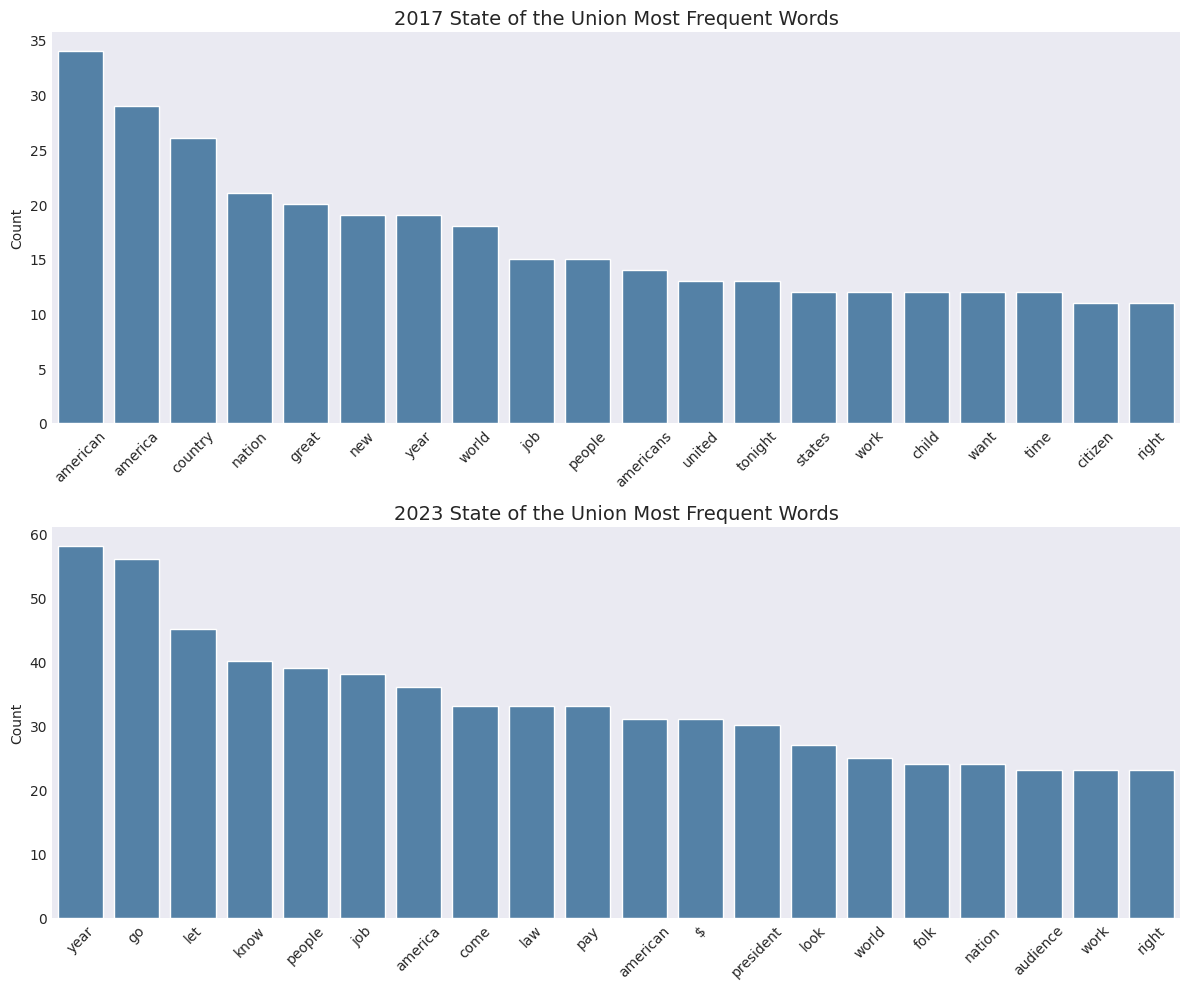

In [164]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

sns.barplot(ax=axes[0], x='Word', y='Count', data=df_2017, color='steelblue')
axes[0].set_title('2017 State of the Union Most Frequent Words', fontsize=14)
axes[0].set_xlabel('') 
axes[0].tick_params(axis='x', rotation=45) 
axes[0].grid(False) 


sns.barplot(ax=axes[1], x='Word', y='Count', data=df_2023, color='steelblue')
axes[1].set_title('2023 State of the Union Most Frequent Words', fontsize=14)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45) 
axes[1].grid(False) 

plt.tight_layout() 
figure_filepath = os.path.join(OUTPUT_DIR, 'sotu_word_comparison_barplots.png')
plt.savefig(figure_filepath, bbox_inches='tight') 
plt.show()

These barplots show the count of the top n=20 lemmas using the function created previously, get_most_common_words(df, year, n), in two different years, 2017 and 2023 from the State of the Union (sou) dataset. In 2017 the lemma with the highest count is "american" and in 2023 it is "year". 

In [133]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

#### Train the Vectorizer and Transform the Data

In [140]:
raw_docs = sou["Text"].to_list()

In [141]:
np.random.seed(42)

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(raw_docs)
tfidf_array = tfidf_matrix.toarray()

pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(tfidf_matrix)

The output of fit_transform() will be a matrix where each row corresponds to a speech, each column corresponds to a word in the corpus of speeches, and the value is the TF-IDF score which measures the importance of that word in that speech, relative to the rest of the speeches.

#### Plot Speeches

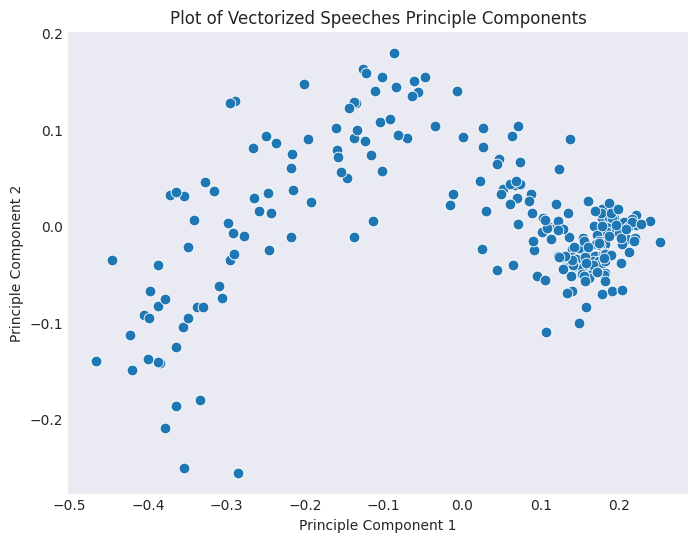

In [165]:
df_pca = pd.DataFrame(data=principal_components, columns=['Principle Component 1', 'Principle Component 2'])
df_pca

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='Principle Component 1', y='Principle Component 2', s=60)

plt.title('Plot of Vectorized Speeches Principle Components')
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')
plt.grid(False)
figure_filepath = os.path.join(OUTPUT_DIR, 'pca_scatterplot.png')
plt.savefig(figure_filepath, bbox_inches='tight') 
plt.show()

This scatterplot plots the correlation between PC1 and PC2 where there seems to increasing in the first half then decreasing in the second half. There is also a cluster happening around 0.2 of PC1 and 0.0 of PC2 which can mean many of the vectorized speeches (data points) have simiar common, high-frequency words. Unlike the left where points are more sparse, these points may represent speeches that are more unique or different from the central cluster and from each other.

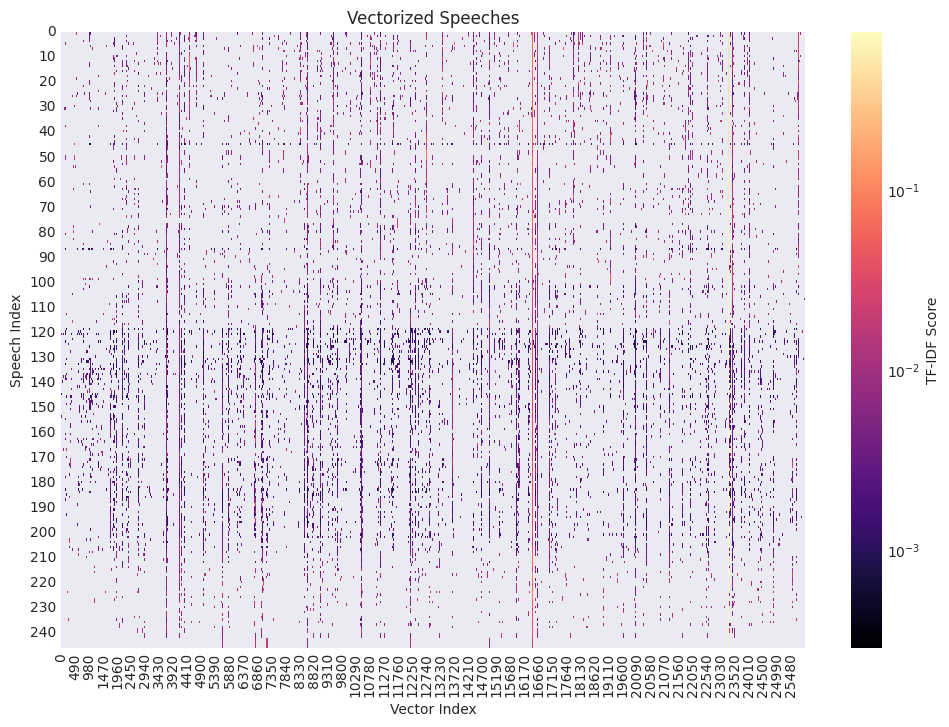

In [166]:
dense_matrix = tfidf_matrix.todense()
n_features = dense_matrix.shape[1]

plt.figure(figsize=(12, 8))
sns.heatmap(dense_matrix, cmap="magma", norm=plt.matplotlib.colors.LogNorm(), cbar_kws={'label': 'TF-IDF Score'})
n_speeches = dense_matrix.shape[0]

y_ticks = np.arange(0, n_speeches + 1, 10) 
y_labels = y_ticks.astype(str)

plt.gca().set_yticks(y_ticks)
plt.gca().set_yticklabels(y_labels, rotation=0)

plt.title("Vectorized Speeches")
plt.xlabel("Vector Index")
plt.ylabel("Speech Index")
figure_filepath = os.path.join(OUTPUT_DIR, 'vectorized_speeches_heatmap.png')
plt.savefig(figure_filepath, bbox_inches='tight') 
plt.show()

In this heatmap, areas where the darker purple is shown is likely to represent a word that is very important to that particular speech but less common across the entire collection of speeches. The dark vertical lines seen near the center and right represent very specific lemmas that appear with a high TF-IDF score in many different speeches.

#### Get the TF-IDF value for certain words and documents

In [114]:
word_list = ['year',
 'america',
 'people',
 'american',
 'work',
 'new',
 'job',
 'country',
 'americans',
 'world'] 

In [115]:
word_nums = [tfidf.vocabulary_.get(word) for word in word_list] 

In [116]:
idf_score = tfidf.idf_[word_nums] 

In [117]:
tf_idf = tfidf_array[0, word_nums]

In [118]:
pd.DataFrame({"Word": word_list, "IDF Score": idf_score, "TF-IDF Score": tf_idf})

,Word,IDF Score,TF-IDF Score
0,year,1.032925,0.048418
1,america,1.272946,0.145857
2,people,1.037118,0.091827
3,american,1.102217,0.097591
4,work,1.162281,0.012107
5,new,1.024591,0.034686
6,job,2.043480,0.021286
7,country,1.008130,0.028879
8,americans,1.713598,0.089249
9,world,1.138750,0.056344
